In [50]:
import numpy as np
import pandas as pd

# We choose Features Wisely After Geeting RF feature Importance
x_col = ['Quality_index', 'Living_Area', 'Luxury_index', 'FullBath', 'YearBuilt', 'SalePrice' ]
train_data = pd.read_csv('Data/final_train.csv', index_col=0)[x_col]
test_data = pd.read_csv('Data/final_test.csv', index_col=0)[x_col]



train_x, train_y = train_data.drop('SalePrice', axis=1), train_data['SalePrice']
test_x, test_y = test_data.drop('SalePrice', axis=1), test_data['SalePrice']

train_x

,Quality_index,Living_Area,Luxury_index,FullBath,YearBuilt
741,5.0,35.628359,3.875578,0.911265,1995
865,3.4,36.329019,0.154925,0.911265,1949
339,5.4,42.542947,5.547298,1.712883,2005
192,3.4,37.573278,0.000000,0.911265,1912
203,3.8,34.079853,4.371354,0.911265,1964
...,...,...,...,...,...
1220,4.4,34.165046,4.159288,1.712883,1998
1185,3.6,33.420319,4.004645,0.911265,1965
1167,4.2,36.102675,4.472627,1.712883,2003
517,4.8,37.475508,1.253723,1.712883,2004


# Model Architecture

In [30]:
from torch import nn

class NNModel(nn.Module):
    def __init__(self, in_f:int, dr:float = 0.3):
        super(NNModel, self).__init__()
        self.input = nn.Linear(in_f, 10*in_f)
        self.hidden1 = nn.Linear(10*in_f, 2*10*in_f)
        self.hidden2 = nn.Linear(2*10*in_f, 10*in_f)
        self.output = nn.Linear(10*in_f, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dr)

    def forward(self, x):
        x = self.relu(self.input(x))

        x = self.relu(self.hidden1(x))
        x = self.dropout(x)

        x = self.relu(self.hidden2(x))
        x = self.dropout(x)

        x = self.output(x)

        return x


model = NNModel(5)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total number of parameters: {num_params} for 5 features input')

Total number of parameters: 10501 for 5 features input


# Model Preparation and training Loop
The idea is two train 5 networks in 5 folds, then use **Majority Voting** function

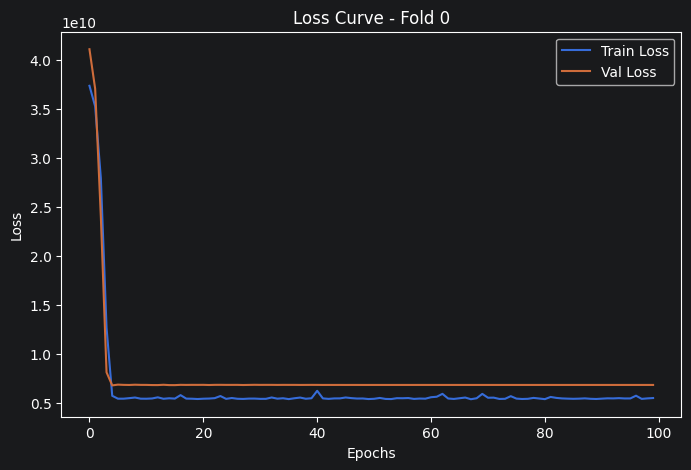

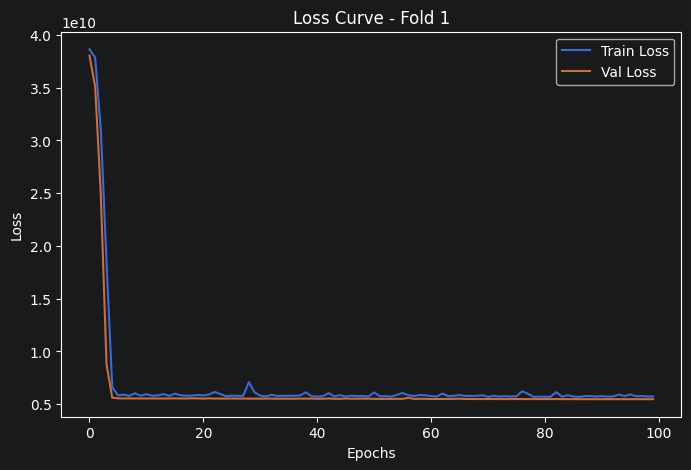

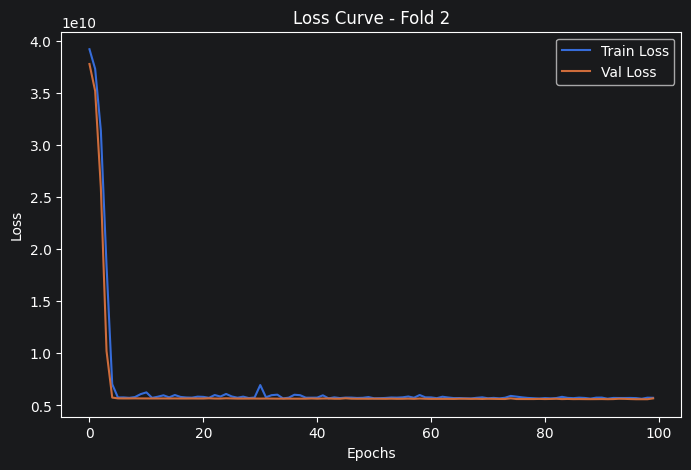

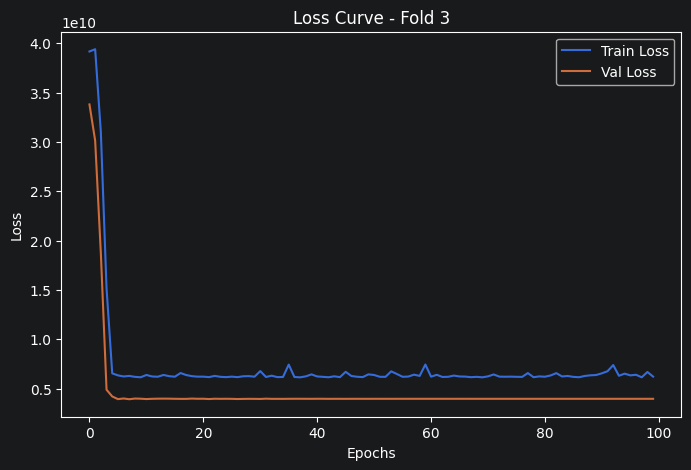

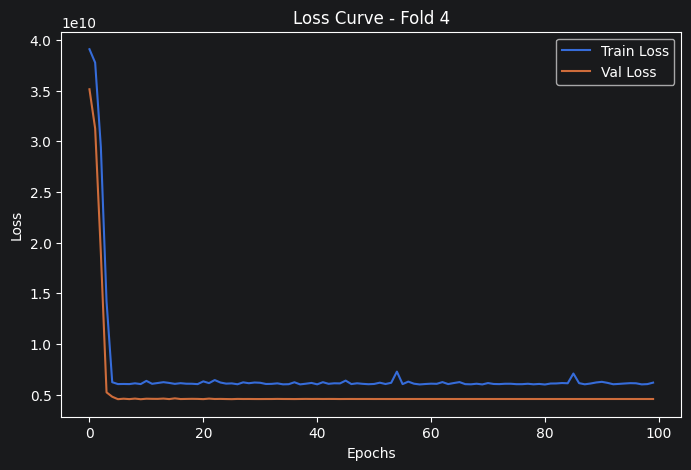

In [44]:
from matplotlib import pyplot as plt
import os
from sklearn.model_selection import KFold
import torch
from torch.optim import lr_scheduler, Adam
from torch.utils.data import TensorDataset, DataLoader, Subset

# dir for models
os.makedirs('Models', exist_ok=True)

#device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data
X_trainval = torch.Tensor(train_x.to_numpy())
y_trainval = torch.Tensor(train_y.to_numpy())
dataset = TensorDataset(X_trainval, y_trainval)

# Hyperparameters
k_FOLDS = 5
N_epochs = 100
batch_size = 32
folds = KFold(n_splits=k_FOLDS, shuffle=True, random_state=42)


#TODO: Cross-validation, optimizer, scheduler, criterion, training loop, etc ...
for fold, (train_index, val_index) in enumerate(folds.split(X_trainval)):
    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=batch_size, shuffle=False)

    #Model, Optimizer and Loss
    model = NNModel(in_f=5, dr=0.3).to(DEVICE)
    optimizer = Adam(model.parameters())
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[], 'lr':[]}
    model.train()

    for epoch in range(N_epochs):
        train_running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            output = model(x).ravel()
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        avg_train_loss = train_running_loss / len(train_loader)

        # Model Validation
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x,y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x).ravel()
                loss = criterion(output, y)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        scheduler.step(avg_val_loss)


        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['lr'].append(current_lr)

        # Saving Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            PATH = os.path.join('Models', f'model_{fold}.pth')
            torch.save(checkpoint, PATH)
            #print(f"Epoch {epoch}: Model Saved with new best loss {avg_val_loss:.4f}")


    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


# Majority Voting

In [66]:
import numpy as np

def mean_response(X:np.ndarray, models:list):
    global DEVICE

    k = len(models)
    for m in models:
        X_tensor = torch.Tensor(X).to(DEVICE)

        m.to(DEVICE).eval()
        with torch.no_grad():
            output = m(X_tensor)
            pred = output.cpu().numpy().mean(axis=1)

    return pred




sample = test_x.to_numpy()[:100]



mean_response(sample, [model, model])

array([182827.47, 186742.55, 183220.7 , 184007.83, 185716.89, 186748.44,
       178076.42, 186031.4 , 187107.23, 175388.89, 186551.88, 177928.1 ,
       181029.94, 186124.66, 186968.98, 179009.  , 183234.44, 186310.92,
       181584.1 , 183743.78, 182647.33, 178317.48, 182961.08, 182120.53,
       186630.69, 178348.66, 182734.95, 186788.38, 186231.67, 186442.39,
       186323.73, 180646.55, 183951.53, 183937.53, 179258.77, 182756.02,
       186305.95, 186809.47, 178104.77, 187917.2 , 180048.52, 182298.72,
       180843.5 , 186540.75, 182727.53, 178774.95, 182749.06, 178598.42,
       183976.27, 186367.7 , 185591.62, 184074.34, 181991.84, 179601.6 ,
       182834.77, 183445.22, 184076.2 , 186134.97, 186747.58, 185357.88,
       185216.72, 180354.98, 177756.77, 186491.1 , 185551.19, 184183.61,
       186640.33, 178454.45, 181368.56, 183650.47, 182604.34, 179304.73,
       185141.84, 182350.94, 186705.5 , 180100.12, 185215.03, 183583.81,
       186588.19, 177491.62, 181894.86, 182314.61, 